# 🛡️ CIC-IDS2017 — Complete Data Cleaning Pipeline
### For Multi-Attack Class Detection with CNN-LSTM

**Attack types in this dataset:**
- BENIGN, DoS Hulk, PortScan, DDoS, DoS GoldenEye, FTP-Patator,
- SSH-Patator, DoS slowloris, DoS Slowhttptest, Bot, Web Attack – Brute Force,
- Web Attack – XSS, Infiltration, Web Attack – Sql Injection, Heartbleed

**Pipeline:**
`Load → Strip/Rename → Drop Duplicates → Fix Inf/NaN → Fix Labels → Drop Zero-Variance → Drop High-Corr → Balance Classes → Export`

## 📦 STEP 0 — Imports

In [1]:
import os, gc, json, warnings
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded ✅')

Libraries loaded ✅


## 📂 STEP 1 — Load All CSVs in Chunks (Memory Safe)

In [2]:
# ── Point this to your dataset folder ──
DATA_DIR = '/kaggle/input/'   # change to your path
CHUNK_SIZE = 100_000

csv_files = glob.glob(DATA_DIR + '**/*.csv', recursive=True)
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    size_mb = os.path.getsize(f) / 1e6
    print(f'  {os.path.basename(f):50s}  {size_mb:.1f} MB')

Found 8 CSV files:
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  76.9 MB
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  52.0 MB
  Tuesday-WorkingHours.pcap_ISCX.csv                  135.1 MB
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv    77.1 MB
  Monday-WorkingHours.pcap_ISCX.csv                   176.9 MB
  Friday-WorkingHours-Morning.pcap_ISCX.csv           58.3 MB
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  83.1 MB
  Wednesday-workingHours.pcap_ISCX.csv                225.2 MB


In [3]:
chunks = []
for path in csv_files:
    for chunk in pd.read_csv(path, chunksize=CHUNK_SIZE, low_memory=False,
                              encoding='utf-8', encoding_errors='replace'):
        chunks.append(chunk)
    print(f'  Loaded: {os.path.basename(path)}')

df_raw = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f'\nRaw shape: {df_raw.shape}')
print(f'RAM used: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

  Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loaded: Tuesday-WorkingHours.pcap_ISCX.csv
  Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loaded: Monday-WorkingHours.pcap_ISCX.csv
  Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loaded: Wednesday-workingHours.pcap_ISCX.csv

Raw shape: (2830743, 79)
RAM used: 1922.9 MB


## 🧹 STEP 2 — Column Name Cleaning

In [4]:
# Strip leading/trailing whitespace from column names (CIC-IDS2017 is notorious for this)
df_raw.columns = df_raw.columns.str.strip()

print('All columns:')
for i, col in enumerate(df_raw.columns):
    print(f'  [{i:02d}] {repr(col)}')

All columns:
  [00] 'Destination Port'
  [01] 'Flow Duration'
  [02] 'Total Fwd Packets'
  [03] 'Total Backward Packets'
  [04] 'Total Length of Fwd Packets'
  [05] 'Total Length of Bwd Packets'
  [06] 'Fwd Packet Length Max'
  [07] 'Fwd Packet Length Min'
  [08] 'Fwd Packet Length Mean'
  [09] 'Fwd Packet Length Std'
  [10] 'Bwd Packet Length Max'
  [11] 'Bwd Packet Length Min'
  [12] 'Bwd Packet Length Mean'
  [13] 'Bwd Packet Length Std'
  [14] 'Flow Bytes/s'
  [15] 'Flow Packets/s'
  [16] 'Flow IAT Mean'
  [17] 'Flow IAT Std'
  [18] 'Flow IAT Max'
  [19] 'Flow IAT Min'
  [20] 'Fwd IAT Total'
  [21] 'Fwd IAT Mean'
  [22] 'Fwd IAT Std'
  [23] 'Fwd IAT Max'
  [24] 'Fwd IAT Min'
  [25] 'Bwd IAT Total'
  [26] 'Bwd IAT Mean'
  [27] 'Bwd IAT Std'
  [28] 'Bwd IAT Max'
  [29] 'Bwd IAT Min'
  [30] 'Fwd PSH Flags'
  [31] 'Bwd PSH Flags'
  [32] 'Fwd URG Flags'
  [33] 'Bwd URG Flags'
  [34] 'Fwd Header Length'
  [35] 'Bwd Header Length'
  [36] 'Fwd Packets/s'
  [37] 'Bwd Packets/s'
  [38] 'Min 

In [5]:
# ── Auto-detect label column ──
label_candidates = [c for c in df_raw.columns if 'label' in c.lower()]
print('Label column candidates:', label_candidates)

LABEL_COL = label_candidates[0]  # usually 'Label'
print(f'Using: {repr(LABEL_COL)}')

# Drop unnamed index columns if present (common in CIC exports)
unnamed_cols = [c for c in df_raw.columns if 'unnamed' in c.lower()]
if unnamed_cols:
    df_raw.drop(columns=unnamed_cols, inplace=True)
    print(f'Dropped unnamed columns: {unnamed_cols}')

Label column candidates: ['Label']
Using: 'Label'


## 🏷️ STEP 3 — Label Audit & Normalization

In [6]:
print('=== RAW LABEL DISTRIBUTION ===')
raw_counts = df_raw[LABEL_COL].value_counts()
print(raw_counts)
print(f'\nTotal unique labels: {df_raw[LABEL_COL].nunique()}')

=== RAW LABEL DISTRIBUTION ===
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total unique labels: 15


In [7]:
# ── Normalize labels: strip whitespace, fix casing inconsistencies ──
df_raw[LABEL_COL] = df_raw[LABEL_COL].astype(str).str.strip()

# ── Canonical label mapping for CIC-IDS2017 ──
# Merges near-duplicate or rare variants into clean class names
LABEL_MAP = {
    # DoS attacks
    'DoS Hulk'           : 'DoS-Hulk',
    'DoS GoldenEye'      : 'DoS-GoldenEye',
    'DoS slowloris'      : 'DoS-Slowloris',
    'DoS Slowhttptest'   : 'DoS-SlowHTTPTest',
    # DDoS
    'DDoS'               : 'DDoS',
    # Brute force
    'FTP-Patator'        : 'BruteForce-FTP',
    'SSH-Patator'        : 'BruteForce-SSH',
    # Web attacks
    'Web Attack  Brute Force' : 'WebAttack-BruteForce',
    'Web Attack – Brute Force': 'WebAttack-BruteForce',
    'Web Attack  XSS'         : 'WebAttack-XSS',
    'Web Attack – XSS'        : 'WebAttack-XSS',
    'Web Attack  Sql Injection': 'WebAttack-SQLi',
    'Web Attack – Sql Injection': 'WebAttack-SQLi',
    # Others
    'Bot'                : 'Bot',
    'Infiltration'       : 'Infiltration',
    'Heartbleed'         : 'Heartbleed',
    'PortScan'           : 'PortScan',
    'BENIGN'             : 'BENIGN',
}

df_raw[LABEL_COL] = df_raw[LABEL_COL].replace(LABEL_MAP)

print('=== NORMALIZED LABEL DISTRIBUTION ===')
print(df_raw[LABEL_COL].value_counts())

=== NORMALIZED LABEL DISTRIBUTION ===
Label
BENIGN                        2273097
DoS-Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS-GoldenEye                   10293
BruteForce-FTP                   7938
BruteForce-SSH                   5897
DoS-Slowloris                    5796
DoS-SlowHTTPTest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


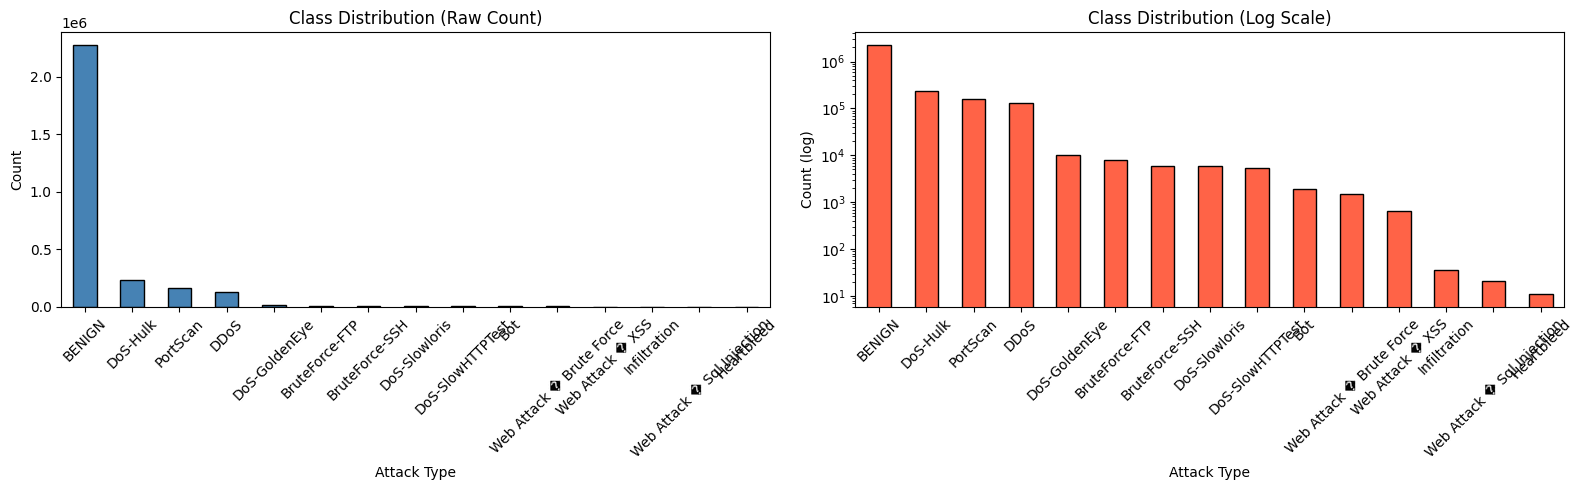


⚠️  Imbalance ratio (BENIGN / smallest attack class):  206645


In [8]:
# ── Visualize class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = df_raw[LABEL_COL].value_counts()

# Raw counts
counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution (Raw Count)')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Log scale (shows minority classes better)
counts.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black', logy=True)
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Count (log)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'\n⚠️  Imbalance ratio (BENIGN / smallest attack class): ',
      round(counts['BENIGN'] / counts.drop('BENIGN').min()))

## 🔢 STEP 4 — Drop Non-Numeric Columns & Force Numeric Types

In [9]:
# Separate features and label
feature_cols = [c for c in df_raw.columns if c != LABEL_COL]

# Coerce all feature columns to numeric (non-parseable → NaN)
df_raw[feature_cols] = df_raw[feature_cols].apply(pd.to_numeric, errors='coerce')

# Report columns that became ALL-NaN (were non-numeric strings)
all_nan_cols = [c for c in feature_cols if df_raw[c].isna().all()]
print(f'Columns that are entirely non-numeric (dropping): {all_nan_cols}')
df_raw.drop(columns=all_nan_cols, inplace=True)
feature_cols = [c for c in feature_cols if c not in all_nan_cols]

print(f'Shape after type coercion: {df_raw.shape}')

Columns that are entirely non-numeric (dropping): []
Shape after type coercion: (2830743, 79)


## ♾️ STEP 5 — Handle Infinity & NaN Values

In [10]:
# Count before
inf_count  = np.isinf(df_raw[feature_cols].values).sum()
nan_count  = df_raw[feature_cols].isna().sum().sum()
print(f'Inf values  : {inf_count:,}')
print(f'NaN values  : {nan_count:,}')
print(f'Total rows  : {len(df_raw):,}')

# Replace inf with NaN
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows where ANY feature is NaN
# (CIC-IDS2017 has very few genuine NaNs — safe to drop)
before = len(df_raw)
df_raw.dropna(inplace=True)
after  = len(df_raw)
print(f'\nRows dropped due to NaN/Inf: {before - after:,}  ({(before-after)/before*100:.2f}%)')
print(f'Rows remaining: {after:,}')

Inf values  : 4,376
NaN values  : 1,358
Total rows  : 2,830,743

Rows dropped due to NaN/Inf: 2,867  (0.10%)
Rows remaining: 2,827,876


## 👯 STEP 6 — Remove Duplicate Rows

In [11]:
before = len(df_raw)
df_raw.drop_duplicates(inplace=True)
after  = len(df_raw)
print(f'Duplicates removed: {before - after:,}  ({(before-after)/before*100:.2f}%)')
print(f'Rows remaining: {after:,}')

Duplicates removed: 307,078  (10.86%)
Rows remaining: 2,520,798


## 📉 STEP 7 — Drop Zero-Variance & Near-Zero Variance Features

In [12]:
from sklearn.feature_selection import VarianceThreshold

feature_cols = [c for c in df_raw.columns if c != LABEL_COL]
X_tmp = df_raw[feature_cols]

# Threshold = 0.0 removes only truly constant columns
selector = VarianceThreshold(threshold=0.0)
selector.fit(X_tmp)

zero_var_cols = [feature_cols[i] for i, v in enumerate(selector.variances_) if v == 0.0]
print(f'Zero-variance columns ({len(zero_var_cols)}): {zero_var_cols}')

df_raw.drop(columns=zero_var_cols, inplace=True)
feature_cols = [c for c in df_raw.columns if c != LABEL_COL]
print(f'Shape after zero-variance drop: {df_raw.shape}')

Zero-variance columns (8): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Shape after zero-variance drop: (2520798, 71)


## 🔗 STEP 8 — Remove Highly Correlated Features (>0.95)

In [13]:
CORR_THRESHOLD = 0.95

# Compute on a sample for speed
sample_df = df_raw[feature_cols].sample(n=min(20_000, len(df_raw)), random_state=42)
corr_matrix = sample_df.corr().abs()

# Upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation > threshold
high_corr_cols = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
print(f'High-correlation columns to drop ({len(high_corr_cols)}): {high_corr_cols}')

df_raw.drop(columns=high_corr_cols, inplace=True)
feature_cols = [c for c in df_raw.columns if c != LABEL_COL]
print(f'Shape after correlation drop: {df_raw.shape}')

High-correlation columns to drop (25): ['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Idle Mean', 'Idle Max', 'Idle Min']
Shape after correlation drop: (2520798, 46)


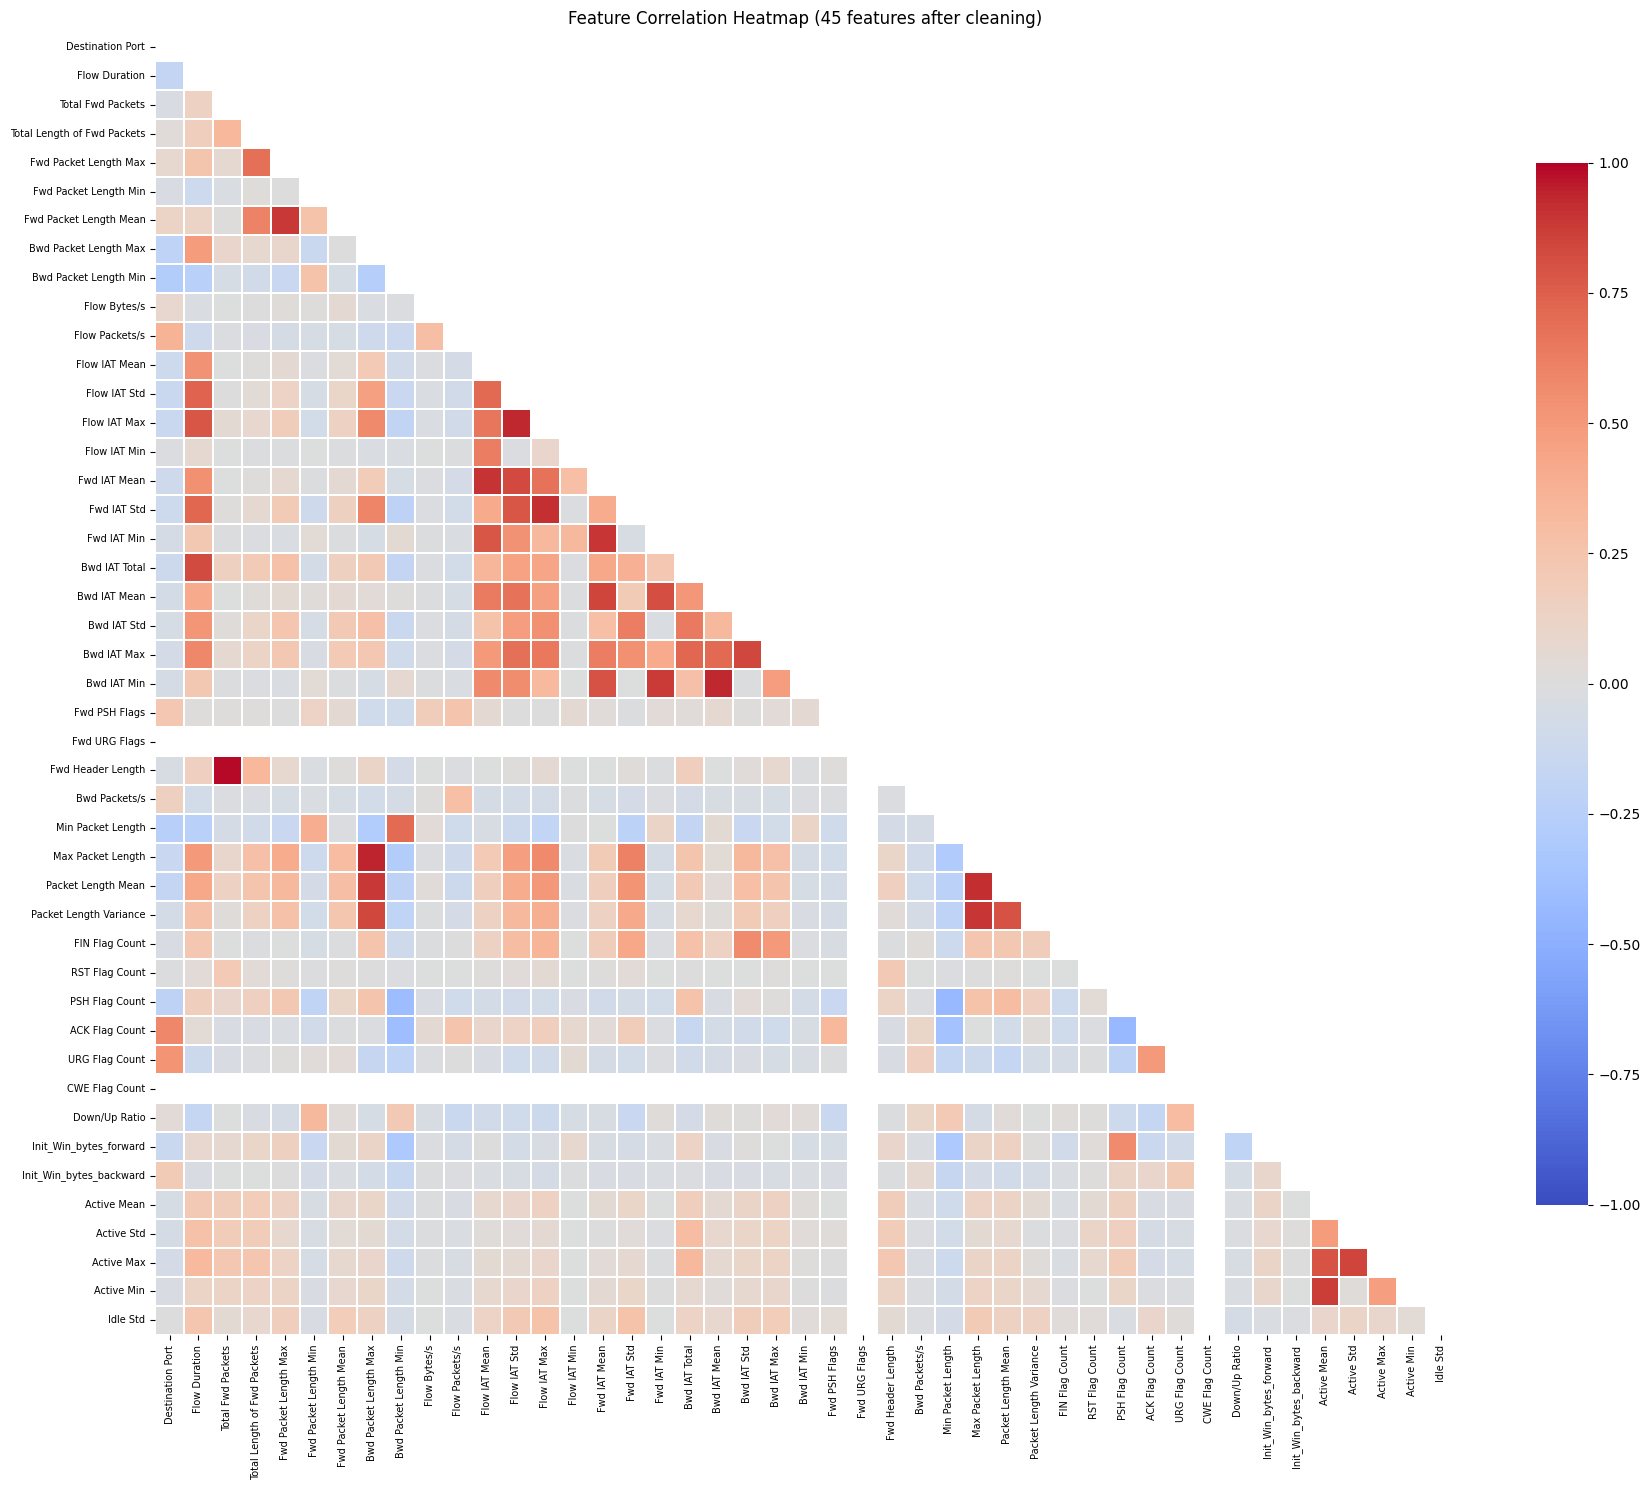

In [14]:
# ── Visualize remaining correlation heatmap ──
sample_corr = df_raw[feature_cols].sample(n=min(10_000, len(df_raw)), random_state=42).corr()

plt.figure(figsize=(18, 15))
mask = np.triu(np.ones_like(sample_corr, dtype=bool))
sns.heatmap(sample_corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.1, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title(f'Feature Correlation Heatmap ({len(feature_cols)} features after cleaning)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## ✂️ STEP 9 — Outlier Clipping (IQR-based, per feature)

In [15]:
# Clip extreme outliers to [Q1 - 3*IQR, Q3 + 3*IQR]
# This is gentler than removal — keeps row count intact

def clip_outliers_iqr(df, cols, multiplier=3.0):
    df = df.copy()
    clipped = 0
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo  = Q1 - multiplier * IQR
        hi  = Q3 + multiplier * IQR
        before = df[col].copy()
        df[col] = df[col].clip(lower=lo, upper=hi)
        clipped += (df[col] != before).sum()
    print(f'Total values clipped: {clipped:,}')
    return df

df_raw = clip_outliers_iqr(df_raw, feature_cols, multiplier=3.0)
gc.collect()
print(f'Shape after outlier clipping: {df_raw.shape}')

Total values clipped: 11,932,394
Shape after outlier clipping: (2520798, 46)


## ⚖️ STEP 10 — Class Balancing (Smart Sampling for Multi-Attack)

In [16]:
# ── Strategy ──
# 1. Cap BENIGN (dominant class) at MAX_BENIGN
# 2. Cap large attack classes at MAX_ATTACK_LARGE
# 3. Oversample tiny attack classes (< MIN_SAMPLES) using resample

from sklearn.utils import resample

MAX_BENIGN        = 50_000   # BENIGN dominates — cap it
MAX_ATTACK_LARGE  = 30_000   # cap large attack classes
MIN_SAMPLES       = 500      # oversample classes below this

class_counts = df_raw[LABEL_COL].value_counts()
balanced_dfs = []

for label, count in class_counts.items():
    class_df = df_raw[df_raw[LABEL_COL] == label]

    if label == 'BENIGN':
        # Downsample BENIGN
        n = min(count, MAX_BENIGN)
        class_df = class_df.sample(n=n, random_state=42)
        print(f'  BENIGN        : {count:>7,}  →  {n:>7,}  (downsampled)')

    elif count > MAX_ATTACK_LARGE:
        # Downsample large attack classes
        n = MAX_ATTACK_LARGE
        class_df = class_df.sample(n=n, random_state=42)
        print(f'  {label:<20}: {count:>7,}  →  {n:>7,}  (downsampled)')

    elif count < MIN_SAMPLES:
        # Oversample minority attack classes
        class_df = resample(class_df, replace=True, n_samples=MIN_SAMPLES, random_state=42)
        print(f'  {label:<20}: {count:>7,}  →  {MIN_SAMPLES:>7,}  (oversampled)')

    else:
        print(f'  {label:<20}: {count:>7,}  →  {count:>7,}  (kept)')

    balanced_dfs.append(class_df)

df_clean = pd.concat(balanced_dfs, ignore_index=True).sample(frac=1, random_state=42)
del balanced_dfs, df_raw
gc.collect()

print(f'\nFinal balanced shape: {df_clean.shape}')
print('\nFinal class counts:')
print(df_clean[LABEL_COL].value_counts())

  BENIGN        : 2,095,057  →   50,000  (downsampled)
  DoS-Hulk            : 172,846  →   30,000  (downsampled)
  DDoS                : 128,014  →   30,000  (downsampled)
  PortScan            :  90,694  →   30,000  (downsampled)
  DoS-GoldenEye       :  10,286  →   10,286  (kept)
  BruteForce-FTP      :   5,931  →    5,931  (kept)
  DoS-Slowloris       :   5,385  →    5,385  (kept)
  DoS-SlowHTTPTest    :   5,228  →    5,228  (kept)
  BruteForce-SSH      :   3,219  →    3,219  (kept)
  Bot                 :   1,948  →    1,948  (kept)
  Web Attack � Brute Force:   1,470  →    1,470  (kept)
  Web Attack � XSS    :     652  →      652  (kept)
  Infiltration        :      36  →      500  (oversampled)
  Web Attack � Sql Injection:      21  →      500  (oversampled)
  Heartbleed          :      11  →      500  (oversampled)

Final balanced shape: (175619, 46)

Final class counts:
Label
BENIGN                        50000
DoS-Hulk                      30000
DDoS                          

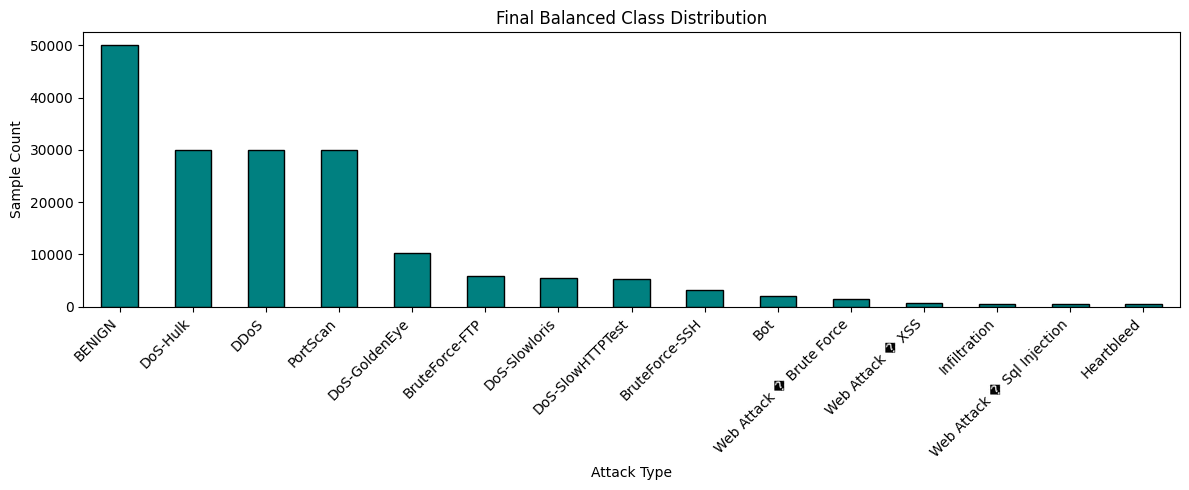

In [17]:
# Visualize final balanced distribution
plt.figure(figsize=(12, 5))
df_clean[LABEL_COL].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Final Balanced Class Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 🔬 STEP 11 — Feature Importance Ranking (Random Forest)

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

feature_cols = [c for c in df_clean.columns if c != LABEL_COL]

le_temp = LabelEncoder()
y_temp  = le_temp.fit_transform(df_clean[LABEL_COL])
X_temp  = df_clean[feature_cols].astype(np.float32).values

# Use a fast RF on subsample
SAMPLE_N = min(30_000, len(X_temp))
idx = np.random.choice(len(X_temp), SAMPLE_N, replace=False)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_temp[idx], y_temp[idx])

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print('Top 25 Features by RF Importance:')
print(importances.head(25).to_string())

del rf, X_temp, y_temp
gc.collect()

Top 25 Features by RF Importance:
Fwd Packet Length Max         0.0682
Total Length of Fwd Packets   0.0647
Fwd Packet Length Mean        0.0603
Bwd Packet Length Max         0.0511
Init_Win_bytes_forward        0.0508
Destination Port              0.0476
Flow Packets/s                0.0461
Bwd Packets/s                 0.0460
Max Packet Length             0.0458
Packet Length Mean            0.0420
Init_Win_bytes_backward       0.0416
Fwd IAT Mean                  0.0402
Flow IAT Max                  0.0399
Flow Duration                 0.0393
Packet Length Variance        0.0344
Total Fwd Packets             0.0322
PSH Flag Count                0.0296
Fwd Header Length             0.0296
Flow IAT Std                  0.0240
Fwd IAT Std                   0.0232
Flow Bytes/s                  0.0220
Bwd Packet Length Min         0.0200
Flow IAT Mean                 0.0193
Fwd Packet Length Min         0.0159
Min Packet Length             0.0154


48

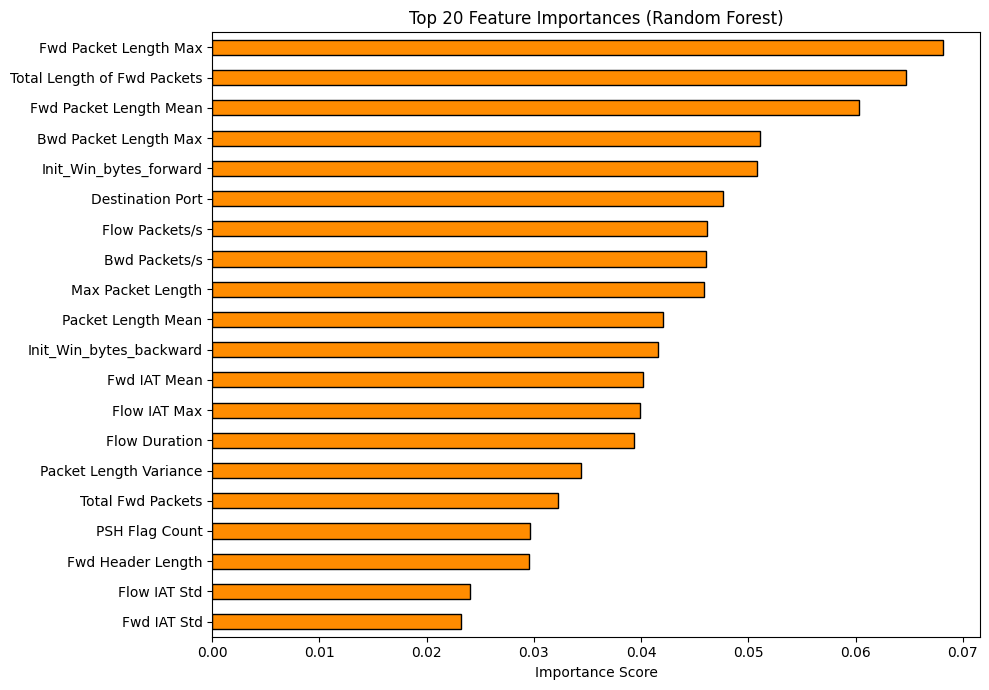


Selected 20 features for CNN-LSTM:
  01. Fwd Packet Length Max
  02. Total Length of Fwd Packets
  03. Fwd Packet Length Mean
  04. Bwd Packet Length Max
  05. Init_Win_bytes_forward
  06. Destination Port
  07. Flow Packets/s
  08. Bwd Packets/s
  09. Max Packet Length
  10. Packet Length Mean
  11. Init_Win_bytes_backward
  12. Fwd IAT Mean
  13. Flow IAT Max
  14. Flow Duration
  15. Packet Length Variance
  16. Total Fwd Packets
  17. PSH Flag Count
  18. Fwd Header Length
  19. Flow IAT Std
  20. Fwd IAT Std


In [19]:
# ── Plot top features ──
TOP_N = 20
TOP_FEATURES = importances.head(TOP_N).index.tolist()

plt.figure(figsize=(10, 7))
importances.head(TOP_N).sort_values().plot(kind='barh', color='darkorange', edgecolor='black')
plt.title(f'Top {TOP_N} Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f'\nSelected {TOP_N} features for CNN-LSTM:')
for i, f in enumerate(TOP_FEATURES, 1):
    print(f'  {i:02d}. {f}')

## 🔐 STEP 12 — Final Dataset Assembly & Type Optimization

In [20]:
# Keep only top features + label
df_final = df_clean[TOP_FEATURES + [LABEL_COL]].copy()

# Downcast float64 → float32 (halves RAM)
for col in TOP_FEATURES:
    df_final[col] = df_final[col].astype(np.float32)

del df_clean
gc.collect()

print('Final cleaned dataset shape:', df_final.shape)
print(f'RAM usage: {df_final.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('\nDtypes:')
print(df_final.dtypes)

Final cleaned dataset shape: (175619, 21)
RAM usage: 25.6 MB

Dtypes:
Fwd Packet Length Max          float32
Total Length of Fwd Packets    float32
Fwd Packet Length Mean         float32
Bwd Packet Length Max          float32
Init_Win_bytes_forward         float32
Destination Port               float32
Flow Packets/s                 float32
Bwd Packets/s                  float32
Max Packet Length              float32
Packet Length Mean             float32
Init_Win_bytes_backward        float32
Fwd IAT Mean                   float32
Flow IAT Max                   float32
Flow Duration                  float32
Packet Length Variance         float32
Total Fwd Packets              float32
PSH Flag Count                 float32
Fwd Header Length              float32
Flow IAT Std                   float32
Fwd IAT Std                    float32
Label                           object
dtype: object


In [21]:
# Final sanity checks
print('=== FINAL DATASET SUMMARY ===')
print(f'Shape          : {df_final.shape}')
print(f'NaN count      : {df_final.isna().sum().sum()}')
print(f'Inf count      : {np.isinf(df_final[TOP_FEATURES].values).sum()}')
print(f'Duplicate rows : {df_final.duplicated().sum()}')
print(f'Unique labels  : {df_final[LABEL_COL].nunique()}')
print()
print('Class distribution:')
print(df_final[LABEL_COL].value_counts())
print()
print('Feature stats (first 5):')
print(df_final[TOP_FEATURES[:5]].describe())

=== FINAL DATASET SUMMARY ===
Shape          : (175619, 21)
NaN count      : 0
Inf count      : 0
Duplicate rows : 24214
Unique labels  : 15

Class distribution:
Label
BENIGN                        50000
DoS-Hulk                      30000
DDoS                          30000
PortScan                      30000
DoS-GoldenEye                 10286
BruteForce-FTP                 5931
DoS-Slowloris                  5385
DoS-SlowHTTPTest               5228
BruteForce-SSH                 3219
Bot                            1948
Web Attack � Brute Force       1470
Web Attack � XSS                652
Infiltration                    500
Web Attack � Sql Injection      500
Heartbleed                      500
Name: count, dtype: int64

Feature stats (first 5):
       Fwd Packet Length Max  Total Length of Fwd Packets  \
count            175619.0000                  175619.0000   
mean                141.2379                     220.7014   
std                 204.3103                     356.4496

## 💾 STEP 13 — Save Cleaned Dataset & Metadata

In [22]:
import joblib
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# ── Encode labels ──
le = LabelEncoder()
df_final['label_encoded'] = le.fit_transform(df_final[LABEL_COL])

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:2d} → {cls}')

# ── Scale features ──
scaler = MinMaxScaler()
df_final[TOP_FEATURES] = scaler.fit_transform(df_final[TOP_FEATURES]).astype(np.float32)

print('\nScaling done ✅')

Label encoding:
   0 → BENIGN
   1 → Bot
   2 → BruteForce-FTP
   3 → BruteForce-SSH
   4 → DDoS
   5 → DoS-GoldenEye
   6 → DoS-Hulk
   7 → DoS-SlowHTTPTest
   8 → DoS-Slowloris
   9 → Heartbleed
  10 → Infiltration
  11 → PortScan
  12 → Web Attack � Brute Force
  13 → Web Attack � Sql Injection
  14 → Web Attack � XSS

Scaling done ✅


In [23]:
# Save cleaned CSV
df_final.to_csv('cicids2017_cleaned.csv', index=False)
print('Saved: cicids2017_cleaned.csv')

# Save scaler & encoder
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le,     'label_encoder.pkl')
print('Saved: scaler.pkl, label_encoder.pkl')

# Save feature list (CRITICAL for inference service)
meta = {
    'top_features'  : TOP_FEATURES,
    'label_col'     : LABEL_COL,
    'num_classes'   : int(len(le.classes_)),
    'class_names'   : list(le.classes_),
    'total_samples' : len(df_final),
}
with open('dataset_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved: dataset_meta.json')
print()
print('✅ Cleaning pipeline complete!')
print(json.dumps(meta, indent=2))

Saved: cicids2017_cleaned.csv
Saved: scaler.pkl, label_encoder.pkl
Saved: dataset_meta.json

✅ Cleaning pipeline complete!
{
  "top_features": [
    "Fwd Packet Length Max",
    "Total Length of Fwd Packets",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Init_Win_bytes_forward",
    "Destination Port",
    "Flow Packets/s",
    "Bwd Packets/s",
    "Max Packet Length",
    "Packet Length Mean",
    "Init_Win_bytes_backward",
    "Fwd IAT Mean",
    "Flow IAT Max",
    "Flow Duration",
    "Packet Length Variance",
    "Total Fwd Packets",
    "PSH Flag Count",
    "Fwd Header Length",
    "Flow IAT Std",
    "Fwd IAT Std"
  ],
  "label_col": "Label",
  "num_classes": 15,
  "class_names": [
    "BENIGN",
    "Bot",
    "BruteForce-FTP",
    "BruteForce-SSH",
    "DDoS",
    "DoS-GoldenEye",
    "DoS-Hulk",
    "DoS-SlowHTTPTest",
    "DoS-Slowloris",
    "Heartbleed",
    "Infiltration",
    "PortScan",
    "Web Attack \ufffd Brute Force",
    "Web Attack \ufffd Sql In

---
## 📋 What Each Step Does — Quick Reference

| Step | Action | Why it matters for multi-attack detection |
|------|---------|--------------------------------------------|
| 1 | Chunked CSV load | Avoids RAM OOM with 8 large day-files |
| 2 | Strip column names | CIC-IDS2017 has hidden spaces in headers |
| 3 | Label normalization | Merges duplicate names (e.g. `Web Attack  XSS` vs `Web Attack – XSS`) |
| 4 | Force numeric types | Some rows have string garbage in numeric cols |
| 5 | Drop Inf/NaN rows | `Flow Bytes/s` and `Flow Packets/s` produce Inf due to 0 duration |
| 6 | Drop duplicates | Prevents data leakage between train/test |
| 7 | Zero-variance drop | Constant columns add noise, waste memory |
| 8 | High-correlation drop | Removes redundant features (e.g. many packet size variants) |
| 9 | Outlier clipping | Extreme values in DoS/DDoS traffic distort LSTM gradients |
| 10 | Smart balancing | Prevents BENIGN from dominating; oversamples rare classes like Heartbleed |
| 11 | RF feature ranking | Selects top-20 most discriminative features |
| 12 | float64 → float32 | Halves RAM usage, compatible with mixed precision training |
| 13 | Save artifacts | `dataset_meta.json` keeps feature list in sync with inference service |

### ⚠️ Common CIC-IDS2017 Gotchas
- **`Flow Bytes/s` and `Flow Packets/s`** — produce `Inf` when flow duration = 0. Always replace inf before dropna.
- **Column name spaces** — `' Label'` vs `'Label'` — always `.strip()` column names first.
- **Heartbleed & Infiltration** have very few samples (<10 each in some files) — oversample or merge if accuracy matters.
- **Web Attack labels** have an em-dash `–` in some files and two spaces `  ` in others — always apply LABEL_MAP.
- **Duplicates are ~10-15%** of the dataset — removing them is critical to avoid inflated accuracy.